<div style="background-color:#a2d9da; padding:15px; border-radius:10px; font-weight:bold;">

This is the Query passed to query stack overflow website to get the data containing nlp tag with atleast one accepted answer


```sql
SELECT
  x.Id                         AS [ID],
  x.Title                      AS [Post Title],
  x.Body                       AS [Description],
  x.CreationDate               AS [Creation Date],
  x.ViewCount                  AS [Views],
  STUFF(
    (
      SELECT ', ' + t.TagName
      FROM PostTags pt
      JOIN Tags t ON t.Id = pt.TagId
      WHERE pt.PostId = x.Id
      FOR XML PATH(''), TYPE
    ).value('.', 'NVARCHAR(MAX)'),
    1, 2, ''
  )                            AS [Tags],
  y.Id                         AS [Accepted Answer ID],
  y.CreationDate               AS [Accepted Answer Creation Date],
  y.Body                       AS [Accepted Answer Body]
FROM Posts x
JOIN PostTags pt ON pt.PostId = x.Id
JOIN Tags t ON t.Id = pt.TagId AND t.TagName = 'nlp'
LEFT JOIN Posts y ON y.Id = x.AcceptedAnswerId
WHERE x.PostTypeId = 1

In [41]:
import pandas as pd 

# THIS OUTPUT IS TO SHOW THAT THE DATAFRAME HAS THE REQUIRED COLUMNS
data = pd.read_csv("QueryResults.csv")
data.head(3)

,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,".net, datetime, nlp",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"language-agnostic, nlp",NaN,NaN,NaN
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"multilingual, speech-recognition, nlp, windows...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m..."


<div style="background-color:#fe130c; padding:15px; border-radius:10px; color:black; font-weight:bold;">

STATISTICAL DETAILS OF THE DATASET (POINT 1 IN RUBRIC)

The value count of number of posts without accepted answer and with accepted answer is 11921 and 8509


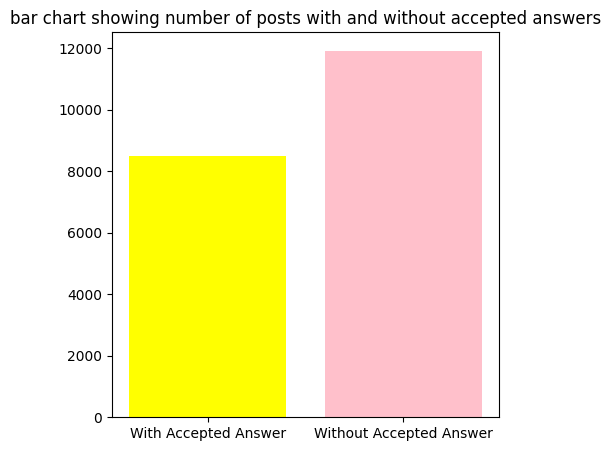

In [42]:
# NUMBER OF POSTS WITHOUT ANY ACCEPTED ANSWER 
import matplotlib.pyplot as plt 

with_accepted_answer, without_accepted_answer = (len(data) - data["Accepted Answer Body"].isna().sum()), data["Accepted Answer Body"].isna().sum()
print(f"The value count of number of posts without accepted answer and with accepted answer is {without_accepted_answer} and {with_accepted_answer}")


plt.figure(figsize = (5, 5))
plt.bar(['With Accepted Answer', 'Without Accepted Answer'], 
        [with_accepted_answer, without_accepted_answer], 
        color=['yellow', 'pink'])
plt.title("bar chart showing number of posts with and without accepted answers")
plt.show()

In [43]:
# HERE WE WILL CALCULATE MEDIAN TIME TO REPLY TO A POST
import statistics as st

data.loc[:, "Creation Date"] = pd.to_datetime(data["Creation Date"])
data.loc[:, "Accepted Answer Creation Date"] = pd.to_datetime(data["Accepted Answer Creation Date"])

# only those posts with accepted answer
data_acc = data[data["Accepted Answer Creation Date"].notna()].copy()

data_acc["Creation Date"] = pd.to_datetime(data_acc["Creation Date"])
data_acc["Accepted Answer Creation Date"] = pd.to_datetime(data_acc["Accepted Answer Creation Date"])
data_acc["reply_time_in_seconds"] = (data_acc["Accepted Answer Creation Date"] - data_acc["Creation Date"]).dt.total_seconds()

median_time_in_seconds = data_acc["reply_time_in_seconds"].median()
mean_time_in_seconds = data_acc["reply_time_in_seconds"].mean()

print("-" * 100)
print(f"\033[1mMedian time to reply to post in seconds: {median_time_in_seconds}\033[0m")
print("-" * 100)
print(f"\033[1mMedian time to reply to post in seconds: {mean_time_in_seconds:.3f}\033[0m")
print("-" * 100)

----------------------------------------------------------------------------------------------------
Median time to reply to post in seconds: 14962.0
----------------------------------------------------------------------------------------------------
Median time to reply to post in seconds: 1456615.455
----------------------------------------------------------------------------------------------------


In [44]:
# AVERAGE NUMBER OF VIEWS ON A POST 
average_number_of_views = data["Views"].mean()

# THIS IS THE SUMMARY THAT SHOWS THE MAXIMUM, MINIMUM AND AVERAGE NUMBER OF VIEWS ON POSTS
data["Views"].describe()

count     20430.000000
mean       2091.337249
std        8840.583748
min           8.000000
25%         166.000000
50%         507.000000
75%        1441.000000
max      472715.000000
Name: Views, dtype: float64

In [ ]:
# THIS SPLISTS BASED ON THE SYMBOL AND MAKES A LIST
def convert_str_list(string):
    return string.split(", ")

# THIS CONVERTS STRING TO LIST
data["Tags"] = data["Tags"].apply(convert_str_list)

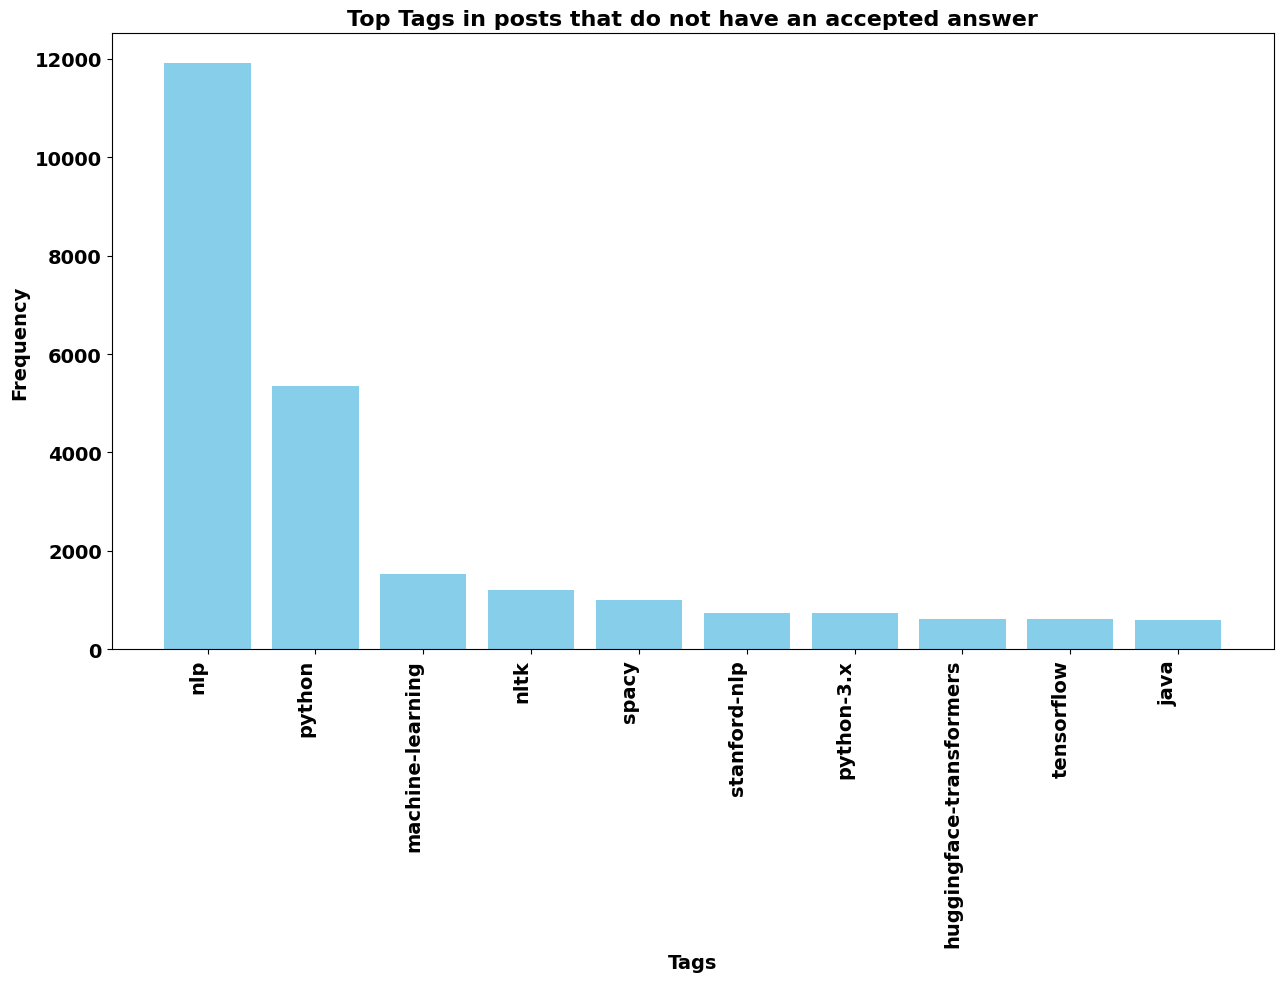

In [ ]:
from collections import Counter

data_without_aans = data[data["Accepted Answer ID"].isna()]

alltags = []
for list_tags in data_without_aans["Tags"]:
    alltags += list_tags

tag_count = Counter(alltags)
alltags_df = pd.DataFrame(tag_count.items(), columns=['Tag', 'Count']).sort_values(by = 'Count', ascending = False)
top10_tags = alltags_df.head(10)


# PLOTS THE PLOT FOR TOP 10 TAGS THAT APPEAR IN POSTS
plt.figure(figsize=(15, 8))
plt.bar(top10_tags['Tag'], top10_tags['Count'], color='skyblue')
plt.title("Top Tags in posts that do not have an accepted answer", fontsize=16, fontweight='bold')
plt.xlabel("Tags", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.show()

<div style="background-color:#fe130c; padding:15px; border-radius:10px; color:black; font-weight:bold;">

CLEANING AND PREPROCESSING TEXT

In [ ]:
# Here we will use beautiful soup to parse the html text in description column
# this is used as we have data in form of html 
# we will use the html.parser to parse the column text
from bs4 import BeautifulSoup

def getting_cleaned_text(text):
    # This will handle NaN values in the accepted answer column
    if pd.isna(text):  
        return ''
    
    soup = BeautifulSoup(text, "html.parser")

    # This piece of code will look for tage that are mentioned below
    # remove the information present between them
    for Tag in soup.find_all(['code', 'pre', 'table', 'img', 'a', 'script', 'style']):
        Tag.decompose()  

    # getting the cleaned text 
    cleaned_text = soup.get_text(separator=' ', strip=True)
    return cleaned_text


data["Processed Description"] = data["Description"].apply(getting_cleaned_text)
data["Processed Accepted Answer"] = data["Accepted Answer Body"].apply(getting_cleaned_text)
# THIS OUTPUT IS TO SHOW THAT THE TEXT IS CLEANED
data.head(3)

,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body,Processed Description,Processed Accepted Answer
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,"[.net, datetime, nlp]",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...,Does anyone know of a .NET date/time parser si...,We developed exactly what you are looking for ...
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"[language-agnostic, nlp]",NaN,NaT,NaN,I'm looking for an existing library to summari...,
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"[multilingual, speech-recognition, nlp, window...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m...","my primary language is spanish, but I use all ...","Citation from Vista : In Windows Vista, Window..."


<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

REMOVING PUNCTUATION AND SYMBOLS

In [ ]:
import re 

# FUNCTION TO REMOVE PUNTUATION AND SYMBOLS
def remove_puntuation_and_symbols(text):
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    return cleaned_text

data["Processed Post Title"] = data["Post Title"].apply(remove_puntuation_and_symbols)
data["Processed Description"] = data["Processed Description"].apply(remove_puntuation_and_symbols) 
data["Processed Accepted Answer"] = data["Processed Accepted Answer"].apply(remove_puntuation_and_symbols)
data.head(3)

,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body,Processed Description,Processed Accepted Answer,Processed Post Title
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,"[.net, datetime, nlp]",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...,Does anyone know of a NET date time parser si...,We developed exactly what you are looking for ...,Natural language date time parser for NET
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"[language-agnostic, nlp]",NaN,NaT,NaN,I m looking for an existing library to summari...,,What s a good natural language library to use ...
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"[multilingual, speech-recognition, nlp, window...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m...",my primary language is spanish but I use all ...,Citation from Vista In Windows Vista Window...,Vista speech recognition in multiple languages


<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

LOWERCASING

In [ ]:
def lowercased_text(text):
    return text.lower()

# PERFORMING LOWERCAING USING THE FUNCTION CREATED ABOVE
data["Processed Post Title"] = data["Processed Post Title"].apply(lowercased_text)
data["Processed Description"] = data["Processed Description"].apply(lowercased_text)
data["Processed Accepted Answer"] = data["Processed Accepted Answer"].apply(lowercased_text)
data.head(3)

,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body,Processed Description,Processed Accepted Answer,Processed Post Title
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,"[.net, datetime, nlp]",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...,does anyone know of a net date time parser si...,we developed exactly what you are looking for ...,natural language date time parser for net
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"[language-agnostic, nlp]",NaN,NaT,NaN,i m looking for an existing library to summari...,,what s a good natural language library to use ...
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"[multilingual, speech-recognition, nlp, window...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m...",my primary language is spanish but i use all ...,citation from vista in windows vista window...,vista speech recognition in multiple languages


<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

TOKENIZATION

In [ ]:
from nltk import word_tokenize

# PERFORMING TOKENIZATION OF THE RESPECTIVE COLUMNS
data["Processed Post Title"] = data["Processed Post Title"].apply(word_tokenize)
data["Processed Description"] = data["Processed Description"].apply(word_tokenize)
data["Processed Accepted Answer"] = data["Processed Accepted Answer"].apply(word_tokenize)
data.head(3)

,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body,Processed Description,Processed Accepted Answer,Processed Post Title
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,"[.net, datetime, nlp]",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...,"[does, anyone, know, of, a, net, date, time, p...","[we, developed, exactly, what, you, are, looki...","[natural, language, date, time, parser, for, net]"
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"[language-agnostic, nlp]",NaN,NaT,NaN,"[i, m, looking, for, an, existing, library, to...",[],"[what, s, a, good, natural, language, library,..."
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"[multilingual, speech-recognition, nlp, window...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m...","[my, primary, language, is, spanish, but, i, u...","[citation, from, vista, in, windows, vista, wi...","[vista, speech, recognition, in, multiple, lan..."


<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

STOP WORD REMOVAL

In [ ]:
import nltk
from nltk.corpus import stopwords

# downloading the stopwords
nltk.download('stopwords')

extra_stop_words = {
    # These are domain specific stopwords that are removed to visualize the words 
    # that are realetd to nlp. These words are important when we will use sentences 
    # in sentence transformer because they take part to provide some contexual information
    # hence they are removed from this but later will be used in sentence transformer
    'text', 'data', 'input', 'output', 'model', 'process', 'file',
    'function', 'use', 'using', 'problem', 'get', 'set', 'used',
    'code', 'example', 'error', 'issue', 'line', 'call', 'type', 'value',
    'check', 'return', 'print', 'run', 'running', 'trying', 'try', 'work',
    'python', 'java', 'c++', 'c', 'r', 'scala', 'javascript', 'js', 'list',
    'string', 'format', 'date', 'files', 'file', 'pretrained', 'loop',
    'post', 'title', 'description', 'answer', 'question', 'stackoverflow',
    'help', 'someone', 'know', 'need', 'thanks', 'anyone', 'thing', 'english',
    'non', 'row', 'column', 'tree', 'train', 'training', 'test', 'testing', 'validation', 'epoch',
    'batch', 'accuracy', 'score', 'loss', 'predict', 'prediction',
    'evaluate', 'evaluation', 'fit', 'fitting', 'fine', 'tune', 'tuning',
    'split', 'dataset', 'samples', 'groundtruth', 'true', 'false', 'result',
    'clean', 'cleaned', 'normal', 'normalize', 'standardize', 'preprocess',
    'remove', 'removed', 'extract', 'create', 'created', 'generate', 'generated',
    'initialize', 'initial', 'loading', 'save', 'loading', 'loaded', 'read', 'write',
    'new', 'old', 'first', 'last', 'second', 'multiple', 'single', 'simple',
    'different', 'same', 'many', 'much', 'big', 'small', 'long', 'short',
    'common', 'general', 'specific', 'normal', 'custom', 'default',
    'like', 'just', 'also', 'would', 'could', 'should', 'want', 'make',
    'still', 'now', 'already', 'way', 'see', 'even', 'well', 'etc', 'working', 'sentence',
    'word', 'finding', 'loop', 'pandas', 'dataframe', 'numpy', 'find', 'pre trained', 
    'getting', 'two', 'natural', 'language', 'pre', 'results', 'implement', 'json', 'tensor',
    'n', 'understanding', 'rows', 'shape', 'within', 'containing', 'words', 'jar', 'module',
    'processing', 'add', 'api', 'based', 'stanford', 'classification', 'sentences', 'based',
    'util', 'good', 'best', 'array', 'time', 'content', 'tweet', 'change', 'given', 'possible', 
    'number', 'name', 'without', 'calculate', 'another'
}


stopwords_set = set(stopwords.words("english")).union(extra_stop_words)

def removing_stopwords(list, set):
    return [word for word in list if word not in set]

# REMOVING THE STOPWPORDS USING CUSTOM STOPWORDS WITH ALL THE WORDS THAT ARE USED IN ENGLISH LANGUAGE
data["Processed Post Title"] = data["Processed Post Title"].apply(lambda tokens: removing_stopwords(tokens, stopwords_set))
data["Processed Description"] = data["Processed Description"].apply(lambda tokens: removing_stopwords(tokens, stopwords_set))
data["Processed Accepted Answer"] = data["Processed Accepted Answer"].apply(lambda tokens: removing_stopwords(tokens, stopwords_set))
data.head(3)

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


,ID,Post Title,Description,Creation Date,Views,Tags,Accepted Answer ID,Accepted Answer Creation Date,Accepted Answer Body,Processed Description,Processed Accepted Answer,Processed Post Title
0,23689,Natural language date/time parser for .NET?,<p>Does anyone know of a .NET date/time parser...,2008-08-22 22:45:10,6486,"[.net, datetime, nlp]",631134.0,2009-03-10 16:36:12,<p>We developed exactly what you are looking f...,"[net, parser, similar, handles, stuff, tomorro...","[developed, exactly, looking, internal, projec...","[parser, net]"
1,25332,What's a good natural language library to use ...,<p>I'm looking for an existing library to summ...,2008-08-24 20:57:33,6492,"[language-agnostic, nlp]",NaN,NaT,NaN,"[looking, existing, library, summarize, paraph...",[],"[library, paraphrasing]"
2,36533,Vista speech recognition in multiple languages,"<p>my primary language is spanish, but I use a...",2008-08-31 01:08:48,5661,"[multilingual, speech-recognition, nlp, window...",36684.0,2008-08-31 08:11:57,"<p>Citation from Vista <a href=""http://blogs.m...","[primary, spanish, software, including, window...","[citation, vista, windows, vista, windows, spe...","[vista, speech, recognition, languages]"


<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

WORD CLOUD POST TITLE

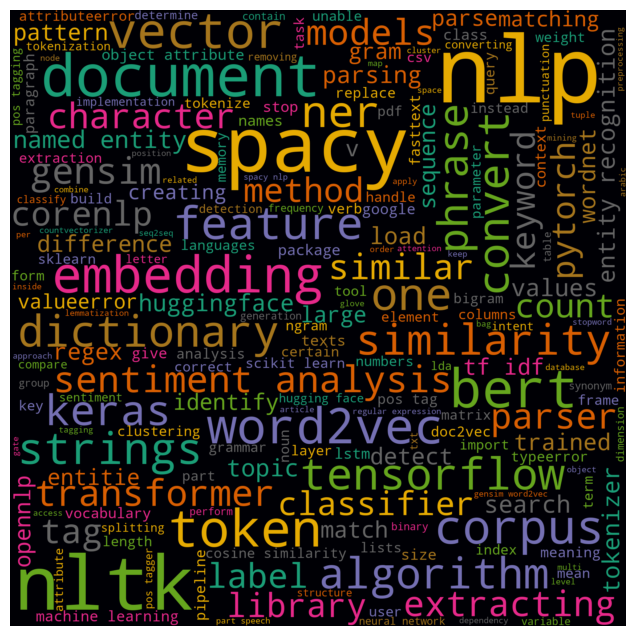

In [ ]:
# This function will be used to make a word cloud by combining strings 
def combine_post_lists(column):
    list_words_titles = []
    for list in column:
        list_words_titles += list

    return list_words_titles

# !pip install --upgrade numpy
# !pip install wordcloud


from wordcloud import WordCloud 
import matplotlib.pyplot as plt

# THIS CONVERTS A STRING OF ALL THE WORDS SEPRATED BY A WHITESPACE
post_title_words = " ".join(combine_post_lists(data["Processed Post Title"]))

# NEXT LINES OF CODE IS TO CREATE A WORDCLOUD
wordcloud_post_title = WordCloud(width=2000,
    height=2000,
    background_color='#000005',
    colormap='Dark2',  
    max_font_size=300,
    prefer_horizontal=0.9,
    contour_color='#fb16fe',
    contour_width=2,
    random_state=42).generate(post_title_words)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud_post_title, interpolation='bilinear')
plt.axis("off")
plt.show()

<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

MODELLING

In [ ]:
%%time 
from sentence_transformers import SentenceTransformer 

# CUSTOM LIST OF CATEGORIES USED FOR CATEGORISATION
categories = [
    "implementation issues or error related questions",
    "conceptual understanding",
    "model evaluation optimization",
    "data preprocessing",
    "feature extraction based questions", 
    "tool or library recommendation",
    "data loading file handling",
    "asking learning resources or advice"
]

data_title = data["Post Title"]
data_cleaned_desc = data["Description"].apply(getting_cleaned_text)

combined_text = data_title + ". " + data_cleaned_desc 
combined_text_list = combined_text.tolist()

# SBERT MODEL USED
model = SentenceTransformer("all-MiniLM-L6-v2")

# CREATE EMBEDDINGS USING THE SENTNECE TRANSFORMER MODEL INSTANCE CREATED ABOVE
sentence_embedding = model.encode(combined_text_list, convert_to_tensor=True, show_progress_bar=True)
label_embeddings = model.encode(categories, convert_to_tensor=True, show_progress_bar=True)

c:\Users\kavis\.conda\envs\DLF\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\kavis\.conda\envs\DLF\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: [WinError 127] The specified procedure could not be found
  warn(f"Failed to load image Python extension: {e}")


Batches: 100%|██████████| 1/1 [00:00<00:00, 32.96it/s]

CPU times: total: 25min 42s
Wall time: 12min 26s


In [ ]:
from sentence_transformers import util
cosine_scores = util.pytorch_cos_sim(sentence_embedding, label_embeddings)

predicted_categories = []

for row in cosine_scores:
    best_idx = row.argmax().item()  # Retrieveing index of highest similarity
    predicted_categories.append(categories[best_idx])

# Form a dataframe of results 
results = pd.DataFrame(list(zip(combined_text_list, predicted_categories)), columns = ["text", "category"])
results

,text,category
0,Natural language date/time parser for .NET?. D...,tool or library recommendation
1,What's a good natural language library to use ...,tool or library recommendation
2,Vista speech recognition in multiple languages...,tool or library recommendation
3,"How do you implement a ""Did you mean""?. Possib...",feature extraction based questions
4,"How to implement a ""related"" degree measure al...",feature extraction based questions
...,...,...
20425,No attention output in jinaai/jina-embeddings-...,model evaluation optimization
20426,How should I approach the word synonyms for re...,feature extraction based questions
20427,Sentencepiece not generating models after prep...,model evaluation optimization
20428,NameError: name 'init_empty_weights' is not de...,model evaluation optimization


In [ ]:
from collections import Counter 

# THIS SHOWS THE NUMBER OF POSTS THAT FALL UNDER EAXH CATEGORY
Counter(results["category"])

Counter({'feature extraction based questions': 7916,
         'tool or library recommendation': 3825,
         'model evaluation optimization': 3773,
         'data preprocessing': 2369,
         'data loading file handling': 1012,
         'conceptual understanding': 773,
         'implementation issues or error related questions': 569,
         'asking learning resources or advice': 193})

<div style="background-color:#DAF7A6; padding:15px; border-radius:10px; color:black; font-weight:bold;">

MANUAL MODEL EVALUATION

In [28]:
# THIS SHOWS THE OUTPUT THAT ARE CATEGORISED AS FEATURE EXTRACTION BASED QUESTIONS
cnt = 1
for i in results[results["category"] == "feature extraction based questions"][:6]["text"]:
    print(f"Question {cnt}")
    print(i)
    print("-"*120)
    cnt+=1

Question 1
How do you implement a "Did you mean"?. Possible Duplicate: Suppose you have a search system already in your website. How can you implement the "Did you mean: " like Google does in some ?
------------------------------------------------------------------------------------------------------------------------
Question 2
How to implement a "related" degree measure algorithm?. I was going to Ask a Question earlier today when I was presented to a surprising functionality in Stackoverflow. When I wrote my question title stackoverflow suggested me several related questions and I found out that there was already two similar questions. That was stunning! Then I started thinking how I would implement such function. How I would order questions by relatedness: Question that have higher number of
words matchs with the new question If the number of matchs are the
same, the order of words is considered Words that appears in the title has
higher relevancy That would be a simple workflow or 

In [30]:
cnt = 1
for i in results[results["category"] == "tool or library recommendation"][:6]["text"]:
    print(f"Question {cnt}")
    print(i)
    print("-"*120)
    cnt+=1

Question 1
Natural language date/time parser for .NET?. Does anyone know of a .NET date/time parser similar to (handles stuff like "tomorrow" or "3pm next thursday")? Note: I do write Ruby (which is how I know about Chronic) but this project must use .NET.
------------------------------------------------------------------------------------------------------------------------
Question 2
What's a good natural language library to use for paraphrasing?. I'm looking for an existing library to summarize or paraphrase content (I'm aiming at blog posts) - any experience with existing natural language processing libraries? I'm open to a variety of languages, so I'm more interested in the abilities & accuracy.
------------------------------------------------------------------------------------------------------------------------
Question 3
Vista speech recognition in multiple languages. my primary language is spanish, but I use all my software in english, including windows; however I'd like to u

In [31]:
cnt = 1
for i in results[results["category"] == "model evaluation optimization"][:6]["text"]:
    print(f"Question {cnt}")
    print(i)
    print("-"*120)
    cnt+=1

Question 1
Algorithm to determine how positive or negative a statement/text is. I need an algorithm to determine if a sentence, paragraph or article is negative or positive in tone... or better yet, how negative or positive. For instance: Jason is the worst SO user I have ever witnessed (-10) Jason is an SO user (0) Jason is the best SO user I have ever seen (+10) Jason is the best at sucking with SO (-10) While, okay at SO, Jason is the worst at doing bad (+10) Not easy, huh? :) I don't expect somebody to explain this algorithm to me, but I assume there is already much work on something like this in academia somewhere. If you can point me to some articles or research, I would love it. Thanks.
------------------------------------------------------------------------------------------------------------------------
Question 2
Code Golf: Number to Words. The code golf series seem to be fairly popular.  I ran across some code that converts a number to its word representation.  Some examples

In [32]:
for i in results[results["category"] == "data preprocessing"][:6]["text"]:
    print(i)
    print("-"*120)

How to read values from numbers written as words?. As we all know numbers can be written either in numerics, or called by their names. While there are a lot of examples to be found that convert 123 into one hundred twenty three, I could not find good examples of how to convert it the other way around. Some of the caveats: cardinal/nominal or ordinal: "one" and "first" common spelling mistakes: "forty"/"fourty" hundreds/thousands: 2100 -> "twenty one hundred" and also "two thousand and one hundred" separators: "eleven hundred fifty two", but also "elevenhundred fiftytwo" or "eleven-hundred fifty-two" and whatnot colloquialisms: "thirty-something" fractions: 'one third', 'two fifths' common names: 'a dozen', 'half' And there are probably more caveats possible that are not yet listed.
Suppose the algorithm needs to be very robust, and even understand spelling mistakes. What fields/papers/studies/algorithms should I read to learn how to write all this?
Where is the information? PS: My fina

In [33]:
for i in results[results["category"] == "data loading file handling"][:6]["text"]:
    print(i)
    print("-"*120)

Compare many text files that contain duplicate "stubs" from the previous and next file and remove duplicate text automatically. I have a large number of text files (1000+) each containing an article from an academic journal. Unfortunately each article's file also contains a "stub" from the end of the previous article (at the beginning) and from the beginning of the next article (at the end). I need to remove these stubs in preparation for running a frequency analysis on the articles because the stubs constitute duplicate data. There is no simple field that marks the beginning and end of each article in all cases. However, the duplicate text does seem to formatted the same and on the same line in both cases. A script that compared each file to the next file and then removed 1 copy of the duplicate text would be perfect. This seems like it would be a pretty common issue when programming so I am surprised that I haven't been able to find anything that does this. The file names sort in ord

In [34]:
for i in results[results["category"] == "conceptual understanding"][:6]["text"]:
    print(i)
    print("-"*120)

Theory: "Lexical Encoding". I am using the term "Lexical Encoding" for my lack of a better one. A Word is arguably the fundamental unit of communication as opposed to a Letter.  Unicode tries to assign a numeric value to each Letter of all known Alphabets.  What is a Letter to one language, is a Glyph to another.  Unicode 5.1 assigns more than 100,000 values to these Glyphs currently.  Out of the approximately 180,000 Words being used in Modern English, it is said that with a vocabulary of about 2,000 Words, you should be able to converse in general terms. A "Lexical Encoding" would encode each Word not each Letter, and encapsulate them within a Sentence. In this example each Token in the String was encoded as an Integer. The Encoding Scheme here simply assigned an int value based on generalised statistical ranking of word usage, and assigned a constant to the question mark. Ultimately, a Word has both a Spelling & Meaning though.  Any "Lexical Encoding" would preserve the meaning and 

In [35]:
# tool or library errors
for i in results[results["category"] == "implementation issues or error related questions"][:6]["text"]:
    print(i)
    print("-"*120)

Limit CPU / Stack for Java method call?. I am using an NLP library (Stanford NER) that throws errors for rare input documents. I plan to eventually isolate these documents and figure out what about them causes the errors, but this is hard to do (I'm running in Hadoop, so I just know the error occurs 17% through split 379/500 or something like that). As an interim solution, I'd like to be able to apply a CPU and memory limit to this particular call. I'm not sure what the best way to do this would be. My first thought is to create a fixed thread pool of one thread and use the timed get() on Future. This would at least give me a wall clock limit which would likely help somewhat. My question is whether there is any way to do better than this with a reasonable amount of effort.
------------------------------------------------------------------------------------------------------------------------
Java Stanford NLP: ArrayIndexOutOfBounds after loading second lexicon. I am using the Stanford 

In [36]:
for i in results[results["category"] == "asking learning resources or advice"][:6]["text"]:
    print(i)
    print("-"*120)

How to get started on Information Extraction?. Could you recommend a training path to start and become very good in Information Extraction. I started reading about it to do one of my hobby project and soon realized that I would have to be good at math (Algebra, Stats, Prob). I have read some of the introductory books on different math topics (and its so much fun). Looking for some guidance. Please help. Update: Just to answer one of the comment. I am more interested in Text Information Extraction.
------------------------------------------------------------------------------------------------------------------------
Multi layer perceptron for OCR. I intend to use a multi layer perceptron network trained with backpropagation (one hidden layer, inputs served as 8x8 bit matrices containing the B/W pixels from the image). The following questions arise: which type of learning should I use: batch or on-line? how could I estimate the right number of nodes in the hidden layer? I intend to proc